# SAPM Assignment: Modern Portfolio Theory using SIM

**Course:** ECON F412 / FIN F311  
**Semester:** 2, 2025-26  
**Topic:** Efficient Frontier and Tangency Portfolio (Markowitz + SIM)

**Group Member 1:** <Tushya Jain, 2023A7PS0150H>  
**Group Member 2:** <Jainam Parekh, 2023A7PS0137H>  
**Group Member 3:** <Shobhit Arya, ID>

## Scope
1. Domestic portfolio with 5 Indian stocks from different sectors using SIM.
2. Efficient frontier and tangency portfolio with risk-free asset.
3. Domestic tangency performance vs passive index.
4. International portfolio with 5 companies + one anchor (index or one additional security) + one metal (gold or silver).
5. Efficient frontier and tangency for international universe.
6. Cross-comparison: domestic vs international vs index benchmarks.

In [7]:
# v1.2
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

from scipy.optimize import minimize

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
TRADING_DAYS = 252

# 3-year window
START_DATE = '2022-04-01'
END_DATE = '2025-03-31'

# RBI DBIE CSV (template-aligned). Keep this file in the notebook folder.
RBI_CSV_PATH = 'rbi_tbill_91d.csv'

def load_rbi_tbill_rate(csv_path):
    tbill = pd.read_csv(csv_path)
    tbill.columns = ['Date', 'Yield']
    tbill['Date'] = pd.to_datetime(tbill['Date'], dayfirst=True, errors='coerce')
    tbill['Yield'] = pd.to_numeric(tbill['Yield'], errors='coerce')
    tbill = tbill[tbill['Yield'] > 0].dropna()
    if tbill.empty:
        raise ValueError('RBI CSV loaded but no valid positive yields found.')
    rf_annual = tbill['Yield'].mean() / 100.0
    return rf_annual

if os.path.exists(RBI_CSV_PATH):
    RF_ANNUAL = load_rbi_tbill_rate(RBI_CSV_PATH)
    rf_source = f'RBI DBIE CSV ({RBI_CSV_PATH})'
else:
    RF_ANNUAL = 0.069
    rf_source = 'Fallback constant 6.9% (RBI CSV not found)'

RF_DAILY = RF_ANNUAL / TRADING_DAYS

# Domestic candidate pool (India, diversified sectors)
domestic_candidates = {
    'RELIANCE.NS': 'Energy',
    'TCS.NS': 'Information Technology',
    'HDFCBANK.NS': 'Banking',
    'SUNPHARMA.NS': 'Pharmaceuticals',
    'MARUTI.NS': 'Automobile',
    'ITC.NS': 'FMCG',
    'HINDUNILVR.NS': 'FMCG',
    'BHARTIARTL.NS': 'Telecom',
    'LT.NS': 'Capital Goods',
    'TATAMOTORS.NS': 'Automobile',
    'AXISBANK.NS': 'Banking',
    'BAJFINANCE.NS': 'Financial Services'
}
domestic_market = '^NSEI'

# International candidate pool
international_company_candidates = {
    'AAPL': 'Technology',
    'MSFT': 'Technology',
    'XOM': 'Energy',
    'CVX': 'Energy',
    'JPM': 'Financials',
    'BAC': 'Financials',
    'JNJ': 'Healthcare',
    'PFE': 'Healthcare',
    'PG': 'Consumer Staples',
    'KO': 'Consumer Staples'
}

# Assignment interpretation controls
international_anchor_choice = 'INDEX'     # 'INDEX' or 'SECURITY'
international_metal_choice = 'GOLD'       # 'GOLD' or 'SILVER'
international_index_candidates = ['^GSPC', '^IXIC']
international_metal_map = {'GOLD': 'GLD', 'SILVER': 'SLV'}
international_market = '^GSPC'

print(f'Analysis period: {START_DATE} to {END_DATE}')
print(f'Risk-free used: {RF_ANNUAL:.2%} p.a. from {rf_source}')
print('Domestic candidate pool size:', len(domestic_candidates))
print('International company candidate pool size:', len(international_company_candidates))
print(f'International mode: anchor={international_anchor_choice}, metal={international_metal_choice}')

Analysis period: 2022-04-01 to 2025-03-31
Risk-free used: 5.49% p.a. from RBI DBIE CSV (rbi_tbill_91d.csv)
Domestic candidate pool size: 12
International company candidate pool size: 10
International mode: anchor=INDEX, metal=GOLD


In [8]:
def download_close_prices(tickers, start_date, end_date, max_attempts=3):
    if isinstance(tickers, str):
        tickers = [tickers]

    frames = []

    for ticker in tickers:
        one = pd.DataFrame()
        last_error = None

        for _ in range(max_attempts):
            try:
                raw = yf.download(
                    ticker,
                    start=start_date,
                    end=end_date,
                    auto_adjust=True,
                    progress=False,
                    threads=False,
                    group_by='column',
                    timeout=30
                )
            except Exception as exc:
                last_error = exc
                continue

            if raw is None or raw.empty:
                continue

            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)

            if 'Close' in raw.columns:
                one = raw[['Close']].rename(columns={'Close': ticker})
            elif 'Adj Close' in raw.columns:
                one = raw[['Adj Close']].rename(columns={'Adj Close': ticker})

            if not one.empty:
                break

        if one.empty:
            print(f'Warning: could not download {ticker}. Last error: {last_error}')
        else:
            frames.append(one)

    if not frames:
        raise ValueError(f'No data downloaded for {tickers}')

    close = pd.concat(frames, axis=1).sort_index()
    close = close.ffill().dropna(how='all')
    close.columns = [str(c) for c in close.columns]
    return close


def prepare_return_table(asset_tickers, market_ticker, start_date, end_date):
    asset_close = download_close_prices(asset_tickers, start_date, end_date)
    market_close = download_close_prices([market_ticker], start_date, end_date).iloc[:, 0].rename('Market')

    asset_ret = asset_close.pct_change()
    market_ret = market_close.pct_change().dropna()

    merged = asset_ret.join(market_ret, how='inner')
    merged = merged.dropna(subset=['Market'])

    available_assets = [
        t for t in asset_tickers
        if t in merged.columns and merged[t].notna().sum() >= 60
    ]

    if len(available_assets) < 2:
        raise ValueError('Too few asset return series available after data cleaning.')

    if len(available_assets) < len(asset_tickers):
        missing = sorted(set(asset_tickers) - set(available_assets))
        print('Dropped assets due to missing data:', missing)

    merged = merged[available_assets + ['Market']]

    if merged.shape[0] < 60:
        raise ValueError('Too few observations after alignment. Please change period/tickers.')

    return merged


def estimate_sim_inputs(return_table, asset_tickers, rf_daily):
    ex = return_table.copy()
    ex[asset_tickers] = ex[asset_tickers] - rf_daily
    ex['Market'] = ex['Market'] - rf_daily

    market_series = ex['Market'].dropna()
    if market_series.shape[0] < 60:
        raise ValueError('Insufficient market observations for regression.')

    market_mean = market_series.mean()
    market_var = market_series.var()

    rows = []

    for ticker in asset_tickers:
        pair = ex[[ticker, 'Market']].dropna()
        if pair.shape[0] < 60:
            print(f'Skipping {ticker}: too few aligned observations.')
            continue

        X = sm.add_constant(pair['Market'])
        y = pair[ticker]
        reg = sm.OLS(y, X).fit()

        alpha = float(reg.params['const'])
        beta = float(reg.params['Market'])
        residual_var = float(reg.mse_resid)

        expected_excess_daily = alpha + beta * market_mean
        total_var_daily = (beta ** 2) * market_var + residual_var

        rows.append({
            'Ticker': ticker,
            'Alpha': alpha,
            'Beta': beta,
            'ResidualVar': residual_var,
            'R2': reg.rsquared,
            'ExpectedExcessDaily': expected_excess_daily,
            'TotalVarDaily': total_var_daily
        })

    if len(rows) < 2:
        raise ValueError('Not enough securities left after regression filtering.')

    sim_table = pd.DataFrame(rows).set_index('Ticker')
    return sim_table, market_mean, market_var


def build_sim_covariance(sim_table, market_var):
    betas = sim_table['Beta'].values
    residual = sim_table['ResidualVar'].values

    cov = np.outer(betas, betas) * market_var
    cov[np.diag_indices_from(cov)] += residual
    return pd.DataFrame(cov, index=sim_table.index, columns=sim_table.index)


def portfolio_return(w, mu):
    return float(w @ mu)


def portfolio_vol(w, cov):
    return float(np.sqrt(w @ cov @ w))


def portfolio_sharpe(w, mu, cov, rf):
    vol = portfolio_vol(w, cov)
    if vol <= 1e-12:
        return np.nan
    return (portfolio_return(w, mu) - rf) / vol


def solve_markowitz(mu, cov, rf):
    n = len(mu)
    w0 = np.ones(n) / n
    bounds = [(0, 1)] * n
    sum_constraint = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

    mvp = minimize(
        fun=lambda w: portfolio_vol(w, cov),
        x0=w0,
        method='SLSQP',
        bounds=bounds,
        constraints=[sum_constraint]
    )

    tangency = minimize(
        fun=lambda w: -portfolio_sharpe(w, mu, cov, rf),
        x0=w0,
        method='SLSQP',
        bounds=bounds,
        constraints=[sum_constraint]
    )

    ret_mvp = portfolio_return(mvp.x, mu)
    max_target = max(np.max(mu) * 1.05, ret_mvp + 0.01)
    target_returns = np.linspace(ret_mvp, max_target, 120)

    frontier_vol = []
    frontier_ret = []

    for t in target_returns:
        constraints = [
            sum_constraint,
            {'type': 'eq', 'fun': lambda w, target=t: portfolio_return(w, mu) - target}
        ]

        opt = minimize(
            fun=lambda w: portfolio_vol(w, cov),
            x0=w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        if opt.success:
            frontier_ret.append(t)
            frontier_vol.append(portfolio_vol(opt.x, cov))

    return {
        'w_mvp': mvp.x,
        'w_tang': tangency.x,
        'ret_mvp': portfolio_return(mvp.x, mu),
        'vol_mvp': portfolio_vol(mvp.x, cov),
        'sharpe_mvp': portfolio_sharpe(mvp.x, mu, cov, rf),
        'ret_tang': portfolio_return(tangency.x, mu),
        'vol_tang': portfolio_vol(tangency.x, cov),
        'sharpe_tang': portfolio_sharpe(tangency.x, mu, cov, rf),
        'frontier_ret': np.array(frontier_ret),
        'frontier_vol': np.array(frontier_vol)
    }


def plot_frontier(solution, rf, title):
    plt.figure(figsize=(10, 6))

    plt.plot(solution['frontier_vol'], solution['frontier_ret'], color='steelblue', lw=2.3, label='Efficient Frontier')

    cml_x = np.linspace(0, max(solution['frontier_vol']) * 1.25, 200)
    cml_y = rf + solution['sharpe_tang'] * cml_x
    plt.plot(cml_x, cml_y, '--', color='darkorange', lw=2, label='Capital Market Line')

    plt.scatter(solution['vol_mvp'], solution['ret_mvp'], marker='D', s=100, color='green', label='MVP')
    plt.scatter(solution['vol_tang'], solution['ret_tang'], marker='*', s=280, color='red', label='Tangency')
    plt.scatter(0, rf, marker='o', s=75, color='black', label='Risk-free')

    plt.title(title)
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Expected Return')
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


def performance_stats(returns, rf_annual):
    returns = returns.dropna()

    cagr = (1 + returns).prod() ** (TRADING_DAYS / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = (cagr - rf_annual) / ann_vol if ann_vol > 1e-12 else np.nan

    wealth = (1 + returns).cumprod()
    max_dd = (wealth / wealth.cummax() - 1).min()

    return pd.Series({
        'CAGR': cagr,
        'Annual Volatility': ann_vol,
        'Sharpe': sharpe,
        'Max Drawdown': max_dd,
        'Terminal Wealth (Base=1)': wealth.iloc[-1]
    })

## Part 1: Domestic Portfolio (SIM Input List, Efficient Frontier, Tangency)

$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


Dropped assets due to missing data: ['TATAMOTORS.NS']
Domestic securities selected: ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'SUNPHARMA.NS', 'MARUTI.NS']
Domestic SIM input list (daily estimates):


,Alpha,Beta,ResidualVar,R2,ExpectedExcessDaily,TotalVarDaily
Ticker,,,,,,
RELIANCE.NS,-0.000290,1.151145,0.000100,0.474213,-0.000056,0.000190
TCS.NS,-0.000245,0.836887,0.000124,0.277609,-0.000075,0.000172
HDFCBANK.NS,-0.000030,1.035393,0.000101,0.420150,0.000181,0.000174
SUNPHARMA.NS,0.000658,0.545027,0.000124,0.140118,0.000769,0.000145
MARUTI.NS,0.000294,0.764805,0.000137,0.226028,0.000449,0.000176


Domestic SIM covariance matrix (daily):


Ticker,RELIANCE.NS,TCS.NS,HDFCBANK.NS,SUNPHARMA.NS,MARUTI.NS
Ticker,,,,,
RELIANCE.NS,0.000190,0.000066,0.000081,0.000043,0.000060
TCS.NS,0.000066,0.000172,0.000059,0.000031,0.000044
HDFCBANK.NS,0.000081,0.000059,0.000174,0.000038,0.000054
SUNPHARMA.NS,0.000043,0.000031,0.000038,0.000145,0.000028
MARUTI.NS,0.000060,0.000044,0.000054,0.000028,0.000176


Domestic portfolio summary:
MVP -> Return: 14.56%, Vol: 13.32%, Sharpe: 0.681
Tangency -> Return: 22.77%, Vol: 16.03%, Sharpe: 1.078


,Sector,Tangency Weight,MVP Weight
Ticker,,,
SUNPHARMA.NS,Pharmaceuticals,0.739951,0.332603
MARUTI.NS,Automobile,0.260049,0.217244
TCS.NS,Information Technology,0.000000,0.207922
HDFCBANK.NS,Banking,0.000000,0.150950
RELIANCE.NS,Energy,0.000000,0.091280


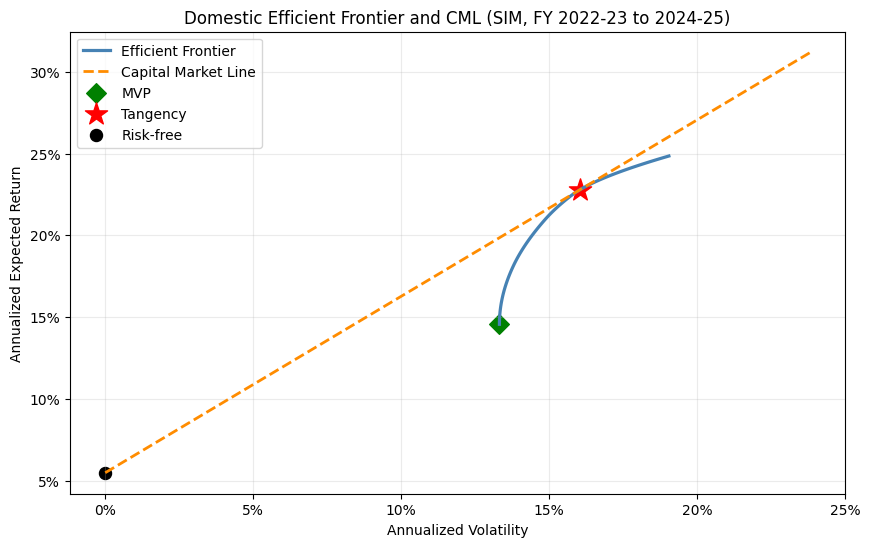

Part 1(c): Domestic optimized portfolio vs passive index


,CAGR,Annual Volatility,Sharpe,Max Drawdown,Terminal Wealth (Base=1)
Domestic Tangency Portfolio,0.239626,0.160369,1.151692,-0.175334,1.877493
NIFTY 50 Passive Index,0.102414,0.130982,0.362523,-0.157667,1.330999


In [12]:
# Part 1: domestic universe
domestic_returns = prepare_return_table(list(domestic_candidates.keys()), domestic_market, START_DATE, END_DATE)

# Pick 5 stocks with good coverage and, as far as possible, different sectors
asset_cols = [c for c in domestic_returns.columns if c != 'Market']
coverage = domestic_returns[asset_cols].notna().sum().sort_values(ascending=False)

sector_used = set()
domestic_tickers = []
for t in coverage.index:
    if coverage[t] < 60:
        continue
    sector = domestic_candidates.get(t, 'Unknown')
    if sector in sector_used:
        continue
    domestic_tickers.append(t)
    sector_used.add(sector)
    if len(domestic_tickers) == 5:
        break

if len(domestic_tickers) < 5:
    for t in coverage.index:
        if coverage[t] < 60 or t in domestic_tickers:
            continue
        domestic_tickers.append(t)
        if len(domestic_tickers) == 5:
            break

if len(domestic_tickers) < 2:
    raise ValueError('Not enough domestic stock data. Check internet and rerun.')

if len(domestic_tickers) < 5:
    print(f'Note: only {len(domestic_tickers)} domestic stocks passed data checks in this run.')

if len(set(domestic_candidates[t] for t in domestic_tickers)) < 5:
    print('Note: fewer than 5 unique sectors due to available data in this run.')

domestic_returns = domestic_returns[domestic_tickers + ['Market']]

domestic_sim, domestic_mkt_mean, domestic_mkt_var = estimate_sim_inputs(
    domestic_returns, domestic_tickers, RF_DAILY
)

domestic_cov_daily = build_sim_covariance(domestic_sim, domestic_mkt_var)

domestic_mu_annual = (domestic_sim['ExpectedExcessDaily'] + RF_DAILY) * TRADING_DAYS
domestic_cov_annual = domestic_cov_daily.values * TRADING_DAYS
domestic_cov_annual += np.eye(domestic_cov_annual.shape[0]) * 1e-8

print('Domestic securities selected:', domestic_tickers)
print('Domestic SIM input list (daily estimates):')
display(domestic_sim)

print('Domestic SIM covariance matrix (daily):')
display(domestic_cov_daily)

domestic_solution = solve_markowitz(domestic_mu_annual.values, domestic_cov_annual, RF_ANNUAL)

domestic_weights = pd.DataFrame({
    'Sector': [domestic_candidates.get(t, 'Unknown') for t in domestic_sim.index],
    'Tangency Weight': domestic_solution['w_tang'],
    'MVP Weight': domestic_solution['w_mvp']
}, index=domestic_sim.index).sort_values('Tangency Weight', ascending=False)

print('Domestic portfolio summary:')
print(f"MVP -> Return: {domestic_solution['ret_mvp']:.2%}, Vol: {domestic_solution['vol_mvp']:.2%}, Sharpe: {domestic_solution['sharpe_mvp']:.3f}")
print(f"Tangency -> Return: {domestic_solution['ret_tang']:.2%}, Vol: {domestic_solution['vol_tang']:.2%}, Sharpe: {domestic_solution['sharpe_tang']:.3f}")
display(domestic_weights)

plot_frontier(domestic_solution, RF_ANNUAL, 'Domestic Efficient Frontier and CML (SIM, FY 2022-23 to 2024-25)')

domestic_portfolio_returns = domestic_returns[domestic_sim.index] @ domestic_solution['w_tang']
domestic_index_returns = domestic_returns['Market']

domestic_perf = pd.DataFrame({
    'Domestic Tangency Portfolio': performance_stats(domestic_portfolio_returns, RF_ANNUAL),
    'NIFTY 50 Passive Index': performance_stats(domestic_index_returns, RF_ANNUAL)
}).T

print('Part 1(c): Domestic optimized portfolio vs passive index')
display(domestic_perf)

## Part 2: International Portfolio (5 Companies + One Anchor + One Metal)

International securities selected: ['AAPL', 'XOM', 'JPM', 'JNJ', 'PG', '^GSPC', 'GLD']
Anchor selected: ^GSPC (mode=INDEX)
Metal selected: GLD (preferred=GLD)
International SIM input list (daily estimates):


,Alpha,Beta,ResidualVar,R2,ExpectedExcessDaily,TotalVarDaily
Ticker,,,,,,
AAPL,0.000111,1.190170,0.000126,0.565010,0.000246,0.000290
XOM,0.000459,0.543669,0.000236,0.126416,0.000521,0.000270
JPM,0.000692,0.865279,0.000146,0.371875,0.000790,0.000233
JNJ,-0.000185,0.215111,0.000101,0.050520,-0.000160,0.000106
PG,0.000011,0.341716,0.000107,0.111607,0.000050,0.000121
^GSPC,-0.000000,1.000000,0.000000,1.000000,0.000114,0.000115
GLD,0.000415,0.180091,0.000078,0.045953,0.000436,0.000082


International SIM covariance matrix (daily):


Ticker,AAPL,XOM,JPM,JNJ,PG,^GSPC,GLD
Ticker,,,,,,,
AAPL,0.000290,0.000075,0.000119,0.000030,0.000047,0.000137,0.000025
XOM,0.000075,0.000270,0.000054,0.000014,0.000021,0.000063,0.000011
JPM,0.000119,0.000054,0.000233,0.000021,0.000034,0.000100,0.000018
JNJ,0.000030,0.000014,0.000021,0.000106,0.000008,0.000025,0.000004
PG,0.000047,0.000021,0.000034,0.000008,0.000121,0.000039,0.000007
^GSPC,0.000137,0.000063,0.000100,0.000025,0.000039,0.000115,0.000021
GLD,0.000025,0.000011,0.000018,0.000004,0.000007,0.000021,0.000082


International portfolio summary:
MVP -> Return: 10.38%, Vol: 9.41%, Sharpe: 0.519
Tangency -> Return: 19.67%, Vol: 12.91%, Sharpe: 1.099


,Asset Class,Tangency Weight,MVP Weight
Ticker,,,
GLD,Gold ETF,0.536396,0.370204
JPM,Financials,0.325172,0.032696
XOM,Energy,0.138433,0.067457
JNJ,Healthcare,0.000000,0.273497
PG,Consumer Staples,0.000000,0.215417
AAPL,Technology,0.000000,0.000000
^GSPC,Index,0.000000,0.040729


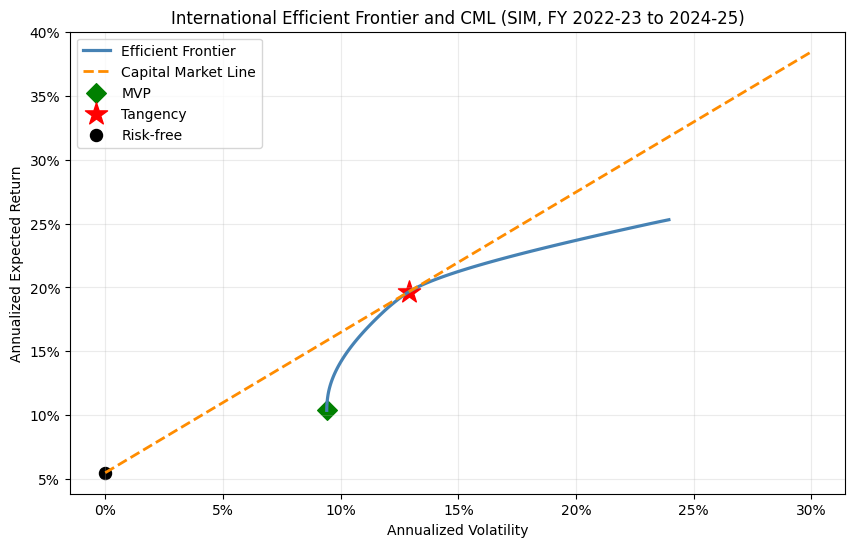

International optimized portfolio vs passive global index


,CAGR,Annual Volatility,Sharpe,Max Drawdown,Terminal Wealth (Base=1)
International Tangency Portfolio,0.207063,0.130196,1.168490,-0.150665,1.749523
S&P 500 Passive Index,0.071457,0.170580,0.096886,-0.219439,1.227697


In [13]:
# Part 2: international universe
intl_all_candidates = list(international_company_candidates.keys()) + international_index_candidates + list(international_metal_map.values())
international_returns = prepare_return_table(intl_all_candidates, international_market, START_DATE, END_DATE)

available_assets = [c for c in international_returns.columns if c != 'Market']
coverage = international_returns[available_assets].notna().sum().sort_values(ascending=False)

# Pick 5 company tickers with sector diversity first
company_candidates_ranked = [
    t for t in coverage.index
    if t in international_company_candidates and coverage[t] >= 60
]

selected_companies = []
company_sectors = set()
for t in company_candidates_ranked:
    sec = international_company_candidates[t]
    if sec in company_sectors:
        continue
    selected_companies.append(t)
    company_sectors.add(sec)
    if len(selected_companies) == 5:
        break

if len(selected_companies) < 5:
    for t in company_candidates_ranked:
        if t in selected_companies:
            continue
        selected_companies.append(t)
        if len(selected_companies) == 5:
            break

if len(selected_companies) < 5:
    raise ValueError('Not enough international companies with valid data in this run.')

# Pick one metal (gold or silver)
preferred_metal = international_metal_map.get(international_metal_choice.upper(), 'GLD')
metal_candidates = [preferred_metal] + [m for m in international_metal_map.values() if m != preferred_metal]
selected_metal = None
for m in metal_candidates:
    if m in coverage.index and coverage[m] >= 60:
        selected_metal = m
        break

if selected_metal is None:
    raise ValueError('Neither GLD nor SLV had enough data in this run.')

# Pick one anchor: either index or one extra security
selected_anchor = None
if international_anchor_choice.upper() == 'INDEX':
    for idx in international_index_candidates:
        if idx in coverage.index and coverage[idx] >= 60:
            selected_anchor = idx
            break
else:
    for t in company_candidates_ranked:
        if t not in selected_companies:
            selected_anchor = t
            break

if selected_anchor is None:
    for idx in international_index_candidates:
        if idx in coverage.index and coverage[idx] >= 60:
            selected_anchor = idx
            break

if selected_anchor is None:
    raise ValueError('Could not select international anchor (index/security).')

international_tickers = selected_companies + [selected_anchor, selected_metal]
international_tickers = list(dict.fromkeys(international_tickers))

if len(set(international_company_candidates[t] for t in selected_companies if t in international_company_candidates)) < 5:
    print('Note: fewer than 5 unique sectors in international companies due to available data.')

if selected_metal != preferred_metal:
    print(f'Note: preferred metal {preferred_metal} unavailable, used {selected_metal}.')

international_returns = international_returns[international_tickers + ['Market']]

international_sim, intl_mkt_mean, intl_mkt_var = estimate_sim_inputs(
    international_returns, international_tickers, RF_DAILY
)

international_cov_daily = build_sim_covariance(international_sim, intl_mkt_var)

international_mu_annual = (international_sim['ExpectedExcessDaily'] + RF_DAILY) * TRADING_DAYS
international_cov_annual = international_cov_daily.values * TRADING_DAYS
international_cov_annual += np.eye(international_cov_annual.shape[0]) * 1e-8

print('International securities selected:', international_tickers)
print(f'Anchor selected: {selected_anchor} (mode={international_anchor_choice})')
print(f'Metal selected: {selected_metal} (preferred={preferred_metal})')
print('International SIM input list (daily estimates):')
display(international_sim)

print('International SIM covariance matrix (daily):')
display(international_cov_daily)

international_solution = solve_markowitz(international_mu_annual.values, international_cov_annual, RF_ANNUAL)

asset_class_map = {}
asset_class_map.update(international_company_candidates)
asset_class_map.update({m: f"{k.title()} ETF" for k, m in international_metal_map.items()})
for idx in international_index_candidates:
    asset_class_map[idx] = 'Index'

international_weights = pd.DataFrame({
    'Asset Class': [asset_class_map.get(t, 'Unknown') for t in international_sim.index],
    'Tangency Weight': international_solution['w_tang'],
    'MVP Weight': international_solution['w_mvp']
}, index=international_sim.index).sort_values('Tangency Weight', ascending=False)

print('International portfolio summary:')
print(f"MVP -> Return: {international_solution['ret_mvp']:.2%}, Vol: {international_solution['vol_mvp']:.2%}, Sharpe: {international_solution['sharpe_mvp']:.3f}")
print(f"Tangency -> Return: {international_solution['ret_tang']:.2%}, Vol: {international_solution['vol_tang']:.2%}, Sharpe: {international_solution['sharpe_tang']:.3f}")
display(international_weights)

plot_frontier(international_solution, RF_ANNUAL, 'International Efficient Frontier and CML (SIM, FY 2022-23 to 2024-25)')

international_portfolio_returns = international_returns[international_sim.index] @ international_solution['w_tang']
international_index_returns = international_returns['Market']

international_perf = pd.DataFrame({
    'International Tangency Portfolio': performance_stats(international_portfolio_returns, RF_ANNUAL),
    'S&P 500 Passive Index': performance_stats(international_index_returns, RF_ANNUAL)
}).T

print('International optimized portfolio vs passive global index')
display(international_perf)

In [14]:
# Part 2(b): Compare international to domestic and benchmarks
import json

common_index = domestic_portfolio_returns.index.intersection(international_portfolio_returns.index)

comparison_returns = pd.DataFrame({
    'Domestic Tangency': domestic_portfolio_returns.loc[common_index],
    'International Tangency': international_portfolio_returns.loc[common_index],
    'NIFTY 50': domestic_returns.loc[common_index, 'Market'],
    'S&P 500': international_returns.loc[common_index, 'Market']
})

comparison_perf = comparison_returns.apply(lambda s: performance_stats(s, RF_ANNUAL)).T
print('Final cross-comparison table')
display(comparison_perf)

dom_best = domestic_weights['Tangency Weight'].idxmax()
intl_best = international_weights['Tangency Weight'].idxmax()

summary_json = {
    'metadata': {
        'period_start': START_DATE,
        'period_end': END_DATE,
        'risk_free_annual': float(RF_ANNUAL)
    },
    'domestic': {
        'universe': domestic_sim.index.tolist(),
        'tangency': {
            'expected_return': float(domestic_solution['ret_tang']),
            'volatility': float(domestic_solution['vol_tang']),
            'sharpe': float(domestic_solution['sharpe_tang']),
            'top_asset': dom_best,
            'top_weight': float(domestic_weights.loc[dom_best, 'Tangency Weight'])
        },
        'benchmark': {
            'name': 'NIFTY 50 Passive Index',
            'cagr': float(domestic_perf.loc['NIFTY 50 Passive Index', 'CAGR'])
        },
        'portfolio_cagr': float(domestic_perf.loc['Domestic Tangency Portfolio', 'CAGR'])
    },
    'international': {
        'universe': international_sim.index.tolist(),
        'tangency': {
            'expected_return': float(international_solution['ret_tang']),
            'volatility': float(international_solution['vol_tang']),
            'sharpe': float(international_solution['sharpe_tang']),
            'top_asset': intl_best,
            'top_weight': float(international_weights.loc[intl_best, 'Tangency Weight'])
        },
        'benchmark': {
            'name': 'S&P 500 Passive Index',
            'cagr': float(international_perf.loc['S&P 500 Passive Index', 'CAGR'])
        },
        'portfolio_cagr': float(international_perf.loc['International Tangency Portfolio', 'CAGR'])
    },
    'cross_comparison': comparison_perf.to_dict(orient='index')
}

with open('assignment_findings.json', 'w', encoding='utf-8') as f:
    json.dump(summary_json, f, indent=2)

print('Saved: assignment_findings.json')

Final cross-comparison table


,CAGR,Annual Volatility,Sharpe,Max Drawdown,Terminal Wealth (Base=1)
Domestic Tangency,0.231220,0.161369,1.092465,-0.181892,1.799840
International Tangency,0.196860,0.130213,1.089986,-0.152872,1.661511
NIFTY 50,0.081285,0.131762,0.200022,-0.168582,1.247081
S&P 500,0.076382,0.172242,0.124543,-0.205614,1.231168


Saved: assignment_findings.json


## Submission checklist
- Fill in names and IDs in Cell 1 before submission.
- Keep `rbi_tbill_91d.csv` in this folder so risk-free rate is read from RBI DBIE data.
- Run all code cells from top to bottom once.
- Confirm generated file: `assignment_findings.json`.
- Create your Word summary separately from `assignment_findings.json`.